In [23]:
import numpy as np 
import pandas as pd
from torchsummaryX import summary
import nibabel                      as nib
import nibabel.freesurfer.mghformat as mgh
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn.metrics
from tqdm import tqdm

import glob
import re

In [24]:
import os 
os.getcwd()


'/ocean/projects/cis230054p/ytam'

In [25]:
# Optional: set project root manually
# os.chdir('<project_root>')

In [26]:
ADNI_actual_used_seg_df = pd.read_csv(r'ADNI_actual_used_seg_2.csv')


In [27]:
ADNI_actual_used_seg_df

,participant_id,session_id,age,sex,diagnosis,split
0,sub-ADNI021S0332,ses-M00,69.9,Male,1,train
1,sub-ADNI021S0332,ses-M06,69.9,Male,1,train
2,sub-ADNI021S0332,ses-M12,69.9,Male,1,train
3,sub-ADNI127S0754,ses-M00,67.7,Female,1,train
4,sub-ADNI127S0754,ses-M06,67.7,Female,1,train
...,...,...,...,...,...,...
2203,sub-ADNI062S1299,ses-M18,71.8,Male,1,train
2204,sub-ADNI062S1299,ses-M24,71.8,Male,1,train
2205,sub-ADNI062S1299,ses-M36,71.8,Male,1,train
2206,sub-ADNI100S0035,ses-M36,76.9,Male,0,train


In [28]:
ADNI_actual_used_seg_df[(ADNI_actual_used_seg_df.diagnosis == 0) | (ADNI_actual_used_seg_df.diagnosis == 1)]

,participant_id,session_id,age,sex,diagnosis,split
0,sub-ADNI021S0332,ses-M00,69.9,Male,1,train
1,sub-ADNI021S0332,ses-M06,69.9,Male,1,train
2,sub-ADNI021S0332,ses-M12,69.9,Male,1,train
3,sub-ADNI127S0754,ses-M00,67.7,Female,1,train
4,sub-ADNI127S0754,ses-M06,67.7,Female,1,train
...,...,...,...,...,...,...
2203,sub-ADNI062S1299,ses-M18,71.8,Male,1,train
2204,sub-ADNI062S1299,ses-M24,71.8,Male,1,train
2205,sub-ADNI062S1299,ses-M36,71.8,Male,1,train
2206,sub-ADNI100S0035,ses-M36,76.9,Male,0,train


In [29]:
!nvidia-smi

Wed May 15 23:45:18 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:3B:00.0 Off |                    0 |
| N/A   30C    P0              54W / 300W |   8393MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Set seg_path

In [30]:
seg_path = r"./fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz"
# img_path = r"fastsurfer_seg_masked\masked_orig_nu_{}_{}.npy"
stacked_path = r"./fastsurfer_stacked/stacked_orig_seg_{}_{}.npy"

In [31]:
seg_path

'/ocean/projects/cis230054p/ytam/fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz'

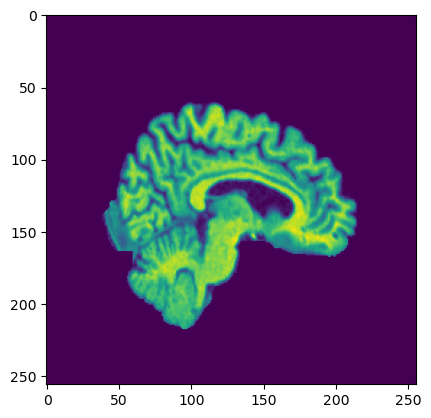

In [32]:
plt.imshow(np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0,120])

In [33]:
read_img = np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0]

In [34]:
read_img.shape

(256, 256, 256)

# Dataset

In [35]:
modal = 'img' # 'seg' for segmentation or 'img' for original mri

In [36]:
import os
import pandas as pd
from torch.utils.data import Dataset
import torch

class ADNIunimodal(Dataset):
    def __init__(self, csv_file, stacked_path, modal = 'seg', split = 'train', transform=None, target_transform=None):
        df = pd.read_csv(csv_file)
        
        if split == 'train':
            self.img_labels = df[df.split == 'train'] 
        elif split == 'val':
            self.img_labels = df[df.split == 'val'] 
        elif split == 'test':
            self.img_labels = df[df.split == 'test'] 
        self.stacked_path = stacked_path
        self.transform = transform
        self.target_transform = target_transform
        self.modal = modal


    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        subject_id = self.img_labels.iloc[idx, 0]
        session_id = self.img_labels.iloc[idx, 1]
        final_path = self.stacked_path.format(subject_id, session_id)
        
        # np load
        if self.modal == 'seg':
            stacked = np.load(final_path)[1] # seg
        if self.modal == 'img':
            stacked = np.load(final_path)[0] # img

        label = self.img_labels.iloc[idx, 4]
        if self.transform:
            stacked = self.transform(stacked)
        if self.target_transform:
            label = self.target_transform(label)
        return stacked, label

In [37]:
train_data = ADNIunimodal(r'ADNI_actual_used_seg_2.csv', stacked_path, modal = modal, split = 'train')
val_data = ADNIunimodal(r'ADNI_actual_used_seg_2.csv', stacked_path, modal = modal, split = 'val')
test_data = ADNIunimodal(r'ADNI_actual_used_seg_2.csv', stacked_path, modal = modal, split = 'test')

# DataLoader

In [38]:
from torch.utils.data import DataLoader
train_batch_size = 6 # smaller_batch
batch_size = 6

train_dataloader = DataLoader(train_data, batch_size=train_batch_size , shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size , shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=batch_size , shuffle=False)

Feature batch shape: torch.Size([256, 256, 256])
Labels batch shape: 0


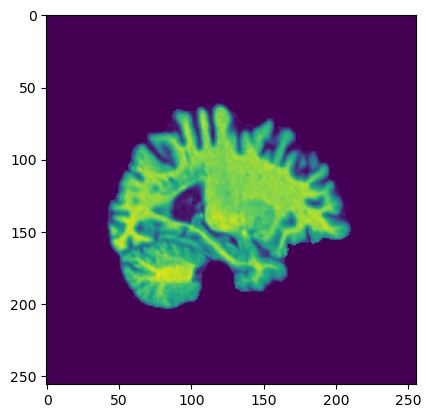

Label: 0


In [39]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features[0].size()}")
print(f"Labels batch shape: {train_labels[0]}")
img = train_features[0][100].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {label}")

# Model

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


# ResNet3D 

In [41]:
W, H, D = 256, 256, 256

from MedicalNet.models import resnet_cls
model = resnet_cls.resnet10(sample_input_W=W,
                sample_input_H=H,
                sample_input_D=D,
                shortcut_type='B',
                no_cuda = False,
                num_classes=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()
# loss_function = torch.nn.BCEWithLogitsLoss()  

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

/ocean/projects/cis230054p/ytam/MedicalNet/models/resnet_cls.py:154: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


In [42]:
PATH = r'MedNet3d_unimodal_img_20231129_103743_f10.9054054054054054_epoch100.pth'

checkpoint = torch.load(PATH)

In [43]:
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_from_checkpoint = checkpoint['epoch']
loss = checkpoint['loss']


In [44]:
from torchsummaryX import summary
for i, data in enumerate(train_dataloader):
    x, y = data
    x = x.float().to(device)
    x = x.reshape(train_batch_size, -1, 256, 256, 256)
    print(x.shape)
    print(y.shape)

    summary(model, x)

    out = model(x)
    print()

    print(out.shape)
    print(out)
    break



torch.Size([6, 1, 256, 256, 256])
torch.Size([6])
                                             Kernel Shape  \
Layer                                                       
0_conv1                                  [1, 64, 7, 7, 7]   
1_bn1                                                [64]   
2_relu                                                  -   
3_maxpool                                               -   
4_layer1.0.Conv3d_conv1                 [64, 64, 3, 3, 3]   
5_layer1.0.BatchNorm3d_bn1                           [64]   
6_layer1.0.ReLU_relu                                    -   
7_layer1.0.Conv3d_conv2                 [64, 64, 3, 3, 3]   
8_layer1.0.BatchNorm3d_bn2                           [64]   
9_layer1.0.ReLU_relu                                    -   
10_layer2.0.Conv3d_conv1               [64, 128, 3, 3, 3]   
11_layer2.0.BatchNorm3d_bn1                         [128]   
12_layer2.0.ReLU_relu                                   -   
13_layer2.0.Conv3d_conv2           

/jet/home/ytam/.local/lib/python3.9/site-packages/torchsummaryX/torchsummaryX.py:101: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_sum = df.sum()


tensor([[-7.9474,  7.9079],
        [-8.2601,  8.2207],
        [ 6.5596, -6.2557],
        [-5.5912,  5.5611],
        [ 6.2104, -5.9689],
        [ 6.7528, -6.4926]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [45]:
try:
    if PATH != None:
        epoch_start = epoch_from_checkpoint
except:
    epoch_start = 0


In [46]:
epoch_start

99

In [47]:
# epoch_start = 0

In [48]:
# val_interval = 2
# best_metric = -1
# best_metric_epoch = -1
# epoch_loss_values = []
# metric_values = []
# writer = SummaryWriter()
# max_epochs = 200
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# train_preds_lst = []
# train_labels_lst = []
# val_preds_lst = []
# val_labels_lst = []

# for epoch in range(epoch_start, max_epochs):
#     print(epoch)
#     model.train()
#     epoch_loss = 0
#     step = 0

#     for batch_data in tqdm(train_dataloader):
#         step += 1
#         inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
#         # inputs shape batchsize
#         inputs = inputs.view(train_batch_size, -1, 256, 256, 256)
#         optimizer.zero_grad()
#         outputs = model(inputs.float())
#         loss = loss_function(outputs, labels)
#         loss.backward()

#         optimizer.step()
#         current_loss = loss.item()
#         epoch_loss += current_loss
#         epoch_len = len(train_data) // train_dataloader.batch_size
#         # print(f"{step}/{epoch_len}, train_loss: {current_loss:.4f}")
#         writer.add_scalar("train_loss", current_loss, epoch_len * epoch + step)
#         with torch.no_grad():
#             train_preds = torch.argmax(torch.nn.functional.softmax(outputs.detach()), dim=1)

#             train_preds_lst.extend(train_preds.detach().cpu().numpy())
#             train_labels_lst.extend(labels.detach().cpu().numpy())

#             # train_f1 = sklearn.metrics.f1_score(labels.detach().cpu().numpy() , train_preds.detach().cpu().numpy(), pos_label = 0)

#     epoch_loss /= step
#     epoch_loss_values.append(epoch_loss)
    
#     train_f1 = sklearn.metrics.f1_score(train_labels_lst, train_preds_lst)
#     print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
#     print("epoch {} train_f1: {}".format(epoch + 1, train_f1))

#     # eval
#     model.eval()

#     for val_data in tqdm(val_dataloader):
#         val_inputs, val_labels = val_data[0].to(device), val_data[1].to(device)

#         # inputs shape batchsize
#         val_inputs = val_inputs.view(batch_size, -1, 256, 256, 256)
#         with torch.no_grad():
#             val_outputs = model(val_inputs.float())
#             val_preds = torch.argmax(torch.nn.functional.softmax(val_outputs.detach()), dim=1)
#             val_preds_lst.extend(val_preds.detach().cpu().numpy())
#             val_labels_lst.extend(val_labels.detach().cpu().numpy())

            
#     val_f1 = sklearn.metrics.f1_score(val_labels_lst, val_preds_lst)
#     metric = val_f1.copy()
#     metric_values.append(metric)
#     print("epoch {} val_f1: {}".format(epoch + 1, val_f1))

#     if metric > best_metric:
#         best_metric = metric
#         best_metric_epoch = epoch + 1
    

#     print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
#     print(f"Best f1: {best_metric:.4f} at epoch {best_metric_epoch}")
#     writer.add_scalar("val_f1", metric, epoch + 1)
    
#     # save checkpoint    
#     torch.save({
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'loss': current_loss,
#         },  "ResNet3d_unimodal_img_{}_f1{}_epoch{}.pth".format(timestamp, metric, epoch+1))
#     print("saved model")

# print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
# writer.close()


In [49]:
# test
test_outputs_lst = []
test_preds_lst = []
test_labels_lst = []


# eval
model.eval()

num_correct = 0.0
metric_count = 0
for test_data in tqdm(test_dataloader):
    test_inputs, test_labels = test_data[0].to(device), test_data[1].to(device)

    # inputs shape batchsize
    test_inputs = test_inputs.view(-1, 1, 256, 256, 256)
    with torch.no_grad():
        test_outputs = model(test_inputs.float())
        test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
        test_outputs_lst.extend(test_outputs.detach().cpu().numpy())
        test_preds_lst.extend(test_preds.detach().cpu().numpy())
        test_labels_lst.extend(test_labels.detach().cpu().numpy())

# metric = num_correct / metric_count
# metric_values.append(metric)

  0%|          | 0/65 [00:00<?, ?it/s]/var/tmp/ipykernel_34563/1188774989.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
100%|██████████| 65/65 [03:38<00:00,  3.35s/it]


In [50]:
# timestamp = timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# torch.save({
#     'epoch': epoch,
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'loss': current_loss,
#     },  "ResNet3d_{}_f1{}_epoch{}.pth".format(timestamp, metric, epoch))

In [51]:
# torch.save(model.state_dict(), "best_metric_ResNet3d_array_epoch{}.pth".format(epoch))



In [52]:
# torch.nn.functional.softmax(torch.Tensor(test_outputs_lst[0]))

In [53]:
# pred_lst = []

# for i in test_outputs_lst:
#     pred = torch.argmax(torch.nn.functional.softmax(torch.Tensor(i)), dim=1)
#     pred_lst.append(pred.numpy()[0])
#     pred_lst.append(pred.numpy()[1])

In [54]:
# sklearn 
import sklearn.metrics

sklearn.metrics.f1_score(test_labels_lst, test_preds_lst)

0.8175182481751826

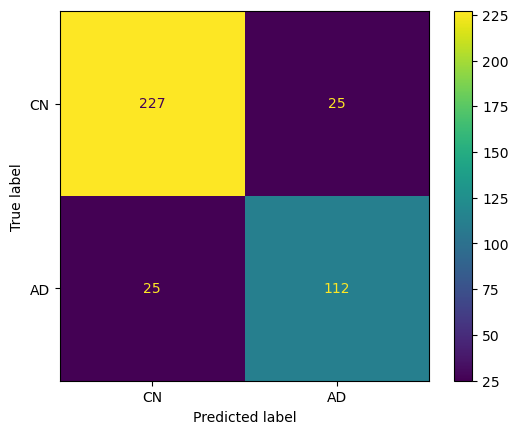

In [55]:
cm = sklearn.metrics.confusion_matrix(test_labels_lst, test_preds_lst)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [56]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_labels_lst, test_preds_lst))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       252
           1       0.82      0.82      0.82       137

    accuracy                           0.87       389
   macro avg       0.86      0.86      0.86       389
weighted avg       0.87      0.87      0.87       389



In [57]:
ADNI_actual_used_seg_df[ADNI_actual_used_seg_df.split == 'test'] # where 0 is AD

,participant_id,session_id,age,sex,diagnosis,split
95,sub-ADNI126S0891,ses-M06,79.3,Female,1,test
96,sub-ADNI126S0891,ses-M12,79.3,Female,1,test
97,sub-ADNI126S0891,ses-M24,79.3,Female,1,test
108,sub-ADNI114S0416,ses-M00,75.6,Female,0,test
109,sub-ADNI114S0416,ses-M06,75.6,Female,0,test
...,...,...,...,...,...,...
2186,sub-ADNI023S0058,ses-M24,70.1,Male,0,test
2187,sub-ADNI023S0058,ses-M48,70.1,Male,0,test
2188,sub-ADNI023S0058,ses-M60,70.1,Male,0,test
2189,sub-ADNI023S0058,ses-M72,70.1,Male,0,test


In [58]:
# continue training

In [59]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]

/var/tmp/ipykernel_34563/382836123.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]
/var/tmp/ipykernel_34563/382836123.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


In [60]:
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

0.9293534932221064

In [61]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

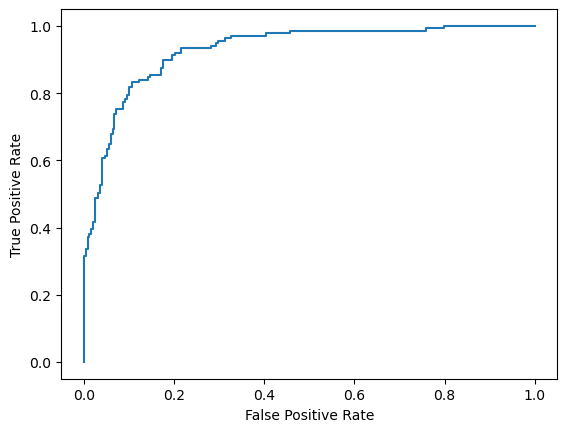

In [62]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [63]:
 sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)

0.8844139090565871

In [64]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

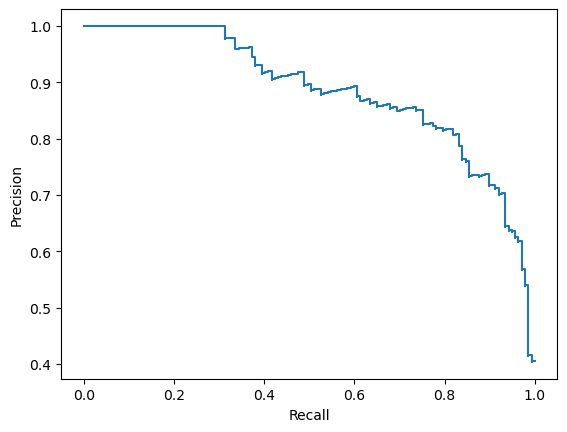

In [65]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [66]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.87146529562982
BA: 0.8591559494844166
AUROC: 0.9293534932221064
AUPRC: 0.8844139090565871


In [67]:
pd.Series(test_preds_lst, name = 'unimodal_mri_pretrain_pred')

0      1
1      1
2      1
3      0
4      0
      ..
384    0
385    0
386    0
387    0
388    0
Name: unimodal_mri_pretrain_pred, Length: 389, dtype: int64

In [68]:
pd.Series(test_prob_preds_lst, name = 'unimodal_mri_pretrain_prob_pred')

0      9.999948e-01
1      9.999993e-01
2      9.999996e-01
3      7.548929e-07
4      1.881165e-07
           ...     
384    1.758132e-05
385    1.072271e-05
386    8.057801e-07
387    1.583633e-05
388    1.007901e-04
Name: unimodal_mri_pretrain_prob_pred, Length: 389, dtype: float32

In [70]:
test_result_df = pd.concat([ADNI_actual_used_seg_df[ADNI_actual_used_seg_df.split == 'test'].reset_index(), pd.Series(test_preds_lst, name = 'unimodal_mri_pretrain_pred'), pd.Series(test_prob_preds_lst, name = 'unimodal_mri_pretrain_prob_pred')],  axis = 1)

In [71]:
test_result_df

,index,participant_id,session_id,age,sex,diagnosis,split,unimodal_mri_pretrain_pred,unimodal_mri_pretrain_prob_pred
0,95,sub-ADNI126S0891,ses-M06,79.3,Female,1,test,1,9.999948e-01
1,96,sub-ADNI126S0891,ses-M12,79.3,Female,1,test,1,9.999993e-01
2,97,sub-ADNI126S0891,ses-M24,79.3,Female,1,test,1,9.999996e-01
3,108,sub-ADNI114S0416,ses-M00,75.6,Female,0,test,0,7.548929e-07
4,109,sub-ADNI114S0416,ses-M06,75.6,Female,0,test,0,1.881165e-07
...,...,...,...,...,...,...,...,...,...
384,2186,sub-ADNI023S0058,ses-M24,70.1,Male,0,test,0,1.758132e-05
385,2187,sub-ADNI023S0058,ses-M48,70.1,Male,0,test,0,1.072271e-05
386,2188,sub-ADNI023S0058,ses-M60,70.1,Male,0,test,0,8.057801e-07
387,2189,sub-ADNI023S0058,ses-M72,70.1,Male,0,test,0,1.583633e-05


In [72]:
test_result_df.to_csv('test_result_df_unimodal_mri_pretrain_pred_epoch_100.csv')